In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv2.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 5
N_TICKS = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]

In [4]:
# метрика лосса: mae где нормировка по корню дисперсии: самое научное, что я придумал/нашел
# + байесовское обучение оптуной, все диапазоны я выбрал интуитивно руководствуясь логикой/статьями, а также по результатам прошлых запусков
def loss_mae(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret"]
    arrs = ["autocorrelation_on_ret", "autocorrelation_on_abs_ret"]
    error = 0
    for i in arrs:
        m_params[i] = m_params[i].mean()
    for i in num + arrs:
        error += abs((t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]) / t_params.loc[t_params["param"] == i, "std"].iloc[0])
    return error / len(num + arrs)

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 20, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 3, 50),
        'Chartist': trial.suggest_int('Chartist', 30, 120),
        'Universalist': trial.suggest_int('Universalist', 5, 50),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 0.05, 100, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 0.005, 10, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -5, 0),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 100, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 100, log=True),
        'Exchange_Volume': trial.suggest_int('Exchange_Volume', 1000, 20000)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(volume=params['Exchange_Volume'], std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'], divs_drifted=True)
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, params['Exchange_Volume']) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, params['Exchange_Volume']) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, params['Exchange_Volume']) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, params['Exchange_Volume']) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, params['Exchange_Volume']) for _ in range(0)],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_mae(target_params, model_params))
        except Exception:
            continue

    if len(errors) != N_RUNS:
        return 1000
    return float(np.mean(errors))

In [5]:
# само обучение
study = optuna.create_study(study_name="calibration_mae_v3 (mm-;volume+;diff diap)", direction="minimize", storage="sqlite:///calibration_mae_3.db",  load_if_exists=True)
study.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study.best_params
best_score = study.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-03-30 11:46:24,926] A new study created in RDB with name: calibration_mae_v3 (mm-;volume+;diff diap)
Best trial: 0. Best value: 3.8515:   0%|          | 1/500 [00:15<2:09:02, 15.52s/it]

[I 2026-03-30 11:46:40,440] Trial 0 finished with value: 3.8515025428023484 and parameters: {'Random': 45, 'Fundamentalist': 30, 'Chartist': 89, 'Universalist': 48, 'Transaction_cost': 0.00045965105709028036, 'Std': 0.13594813557423846, 'Std_Random': 0.011942058743122996, 'Avg_Traders': -3.0805045051920965, 'Last_Step': 0.2653439139421544, 'Last_Ret': 15.175186182572347, 'Noisy_Level': 0.09620689238384747, 'Exchange_Volume': 3629}. Best is trial 0 with value: 3.8515025428023484.


Best trial: 0. Best value: 3.8515:   0%|          | 2/500 [00:41<3:00:56, 21.80s/it]

[I 2026-03-30 11:47:06,642] Trial 1 finished with value: 4.135045803345244 and parameters: {'Random': 51, 'Fundamentalist': 7, 'Chartist': 107, 'Universalist': 36, 'Transaction_cost': 0.04627809150808182, 'Std': 54.34911850183581, 'Std_Random': 0.16533018958181658, 'Avg_Traders': -3.876828077268259, 'Last_Step': 0.25777692254203677, 'Last_Ret': 0.010146843266354856, 'Noisy_Level': 0.004598760906291583, 'Exchange_Volume': 14271}. Best is trial 0 with value: 3.8515025428023484.


Best trial: 0. Best value: 3.8515:   1%|          | 3/500 [01:08<3:21:07, 24.28s/it]

...

[I 2026-03-30 17:45:00,970] Trial 497 finished with value: 0.31825839087311464 and parameters: {'Random': 95, 'Fundamentalist': 29, 'Chartist': 87, 'Universalist': 13, 'Transaction_cost': 0.0032094476240981016, 'Std': 1.2973909364151697, 'Std_Random': 0.8520110630967596, 'Avg_Traders': -1.4653149091859379, 'Last_Step': 0.312880448511137, 'Last_Ret': 0.001443338986409119, 'Noisy_Level': 0.1892520844819358, 'Exchange_Volume': 19269}. Best is trial 287 with value: 0.2577107152481536.


Best trial: 287. Best value: 0.257711: 100%|█████████▉| 499/500 [5:59:26<00:55, 55.95s/it]

[I 2026-03-30 17:45:51,863] Trial 498 finished with value: 0.56384584030503 and parameters: {'Random': 91, 'Fundamentalist': 28, 'Chartist': 88, 'Universalist': 14, 'Transaction_cost': 0.003423802235983249, 'Std': 1.351763678963107, 'Std_Random': 0.8986837459721212, 'Avg_Traders': -1.4473844154490412, 'Last_Step': 0.28887392800804257, 'Last_Ret': 0.0012159148662937045, 'Noisy_Level': 0.25011047278030796, 'Exchange_Volume': 18974}. Best is trial 287 with value: 0.2577107152481536.


Best trial: 287. Best value: 0.257711: 100%|██████████| 500/500 [5:59:56<00:00, 43.19s/it]

[I 2026-03-30 17:46:21,467] Trial 499 finished with value: 6.508284384443885 and parameters: {'Random': 94, 'Fundamentalist': 30, 'Chartist': 86, 'Universalist': 14, 'Transaction_cost': 0.04479100281410217, 'Std': 1.7465180716149076, 'Std_Random': 1.12118817903316, 'Avg_Traders': -1.1956380091928285, 'Last_Step': 0.24444229113730914, 'Last_Ret': 0.0013145833679333624, 'Noisy_Level': 0.19960380697021976, 'Exchange_Volume': 4168}. Best is trial 287 with value: 0.2577107152481536.
Best params: {'Random': 95, 'Fundamentalist': 20, 'Chartist': 77, 'Universalist': 11, 'Transaction_cost': 0.002415770274928675, 'Std': 1.0768021286094103, 'Std_Random': 0.9710317462449651, 'Avg_Traders': -1.5036759605609666, 'Last_Step': 0.30544666930715464, 'Last_Ret': 0.002049868702399675, 'Noisy_Level': 0.6094365914223703, 'Exchange_Volume': 19390}
Best Score: 0.2577107152481536


C:\Users\rodion\AppData\Local\Temp\ipykernel_10716\2255301814.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


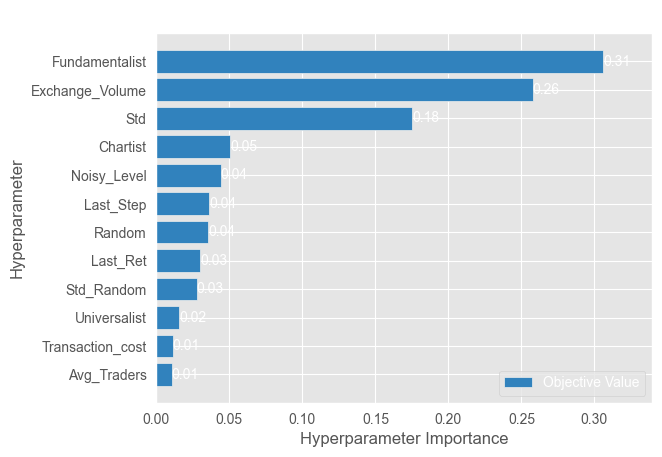

In [6]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

plot_param_importances(study)
plt.show()